## Part A: Loading in Data

## 0 Install dependencies

This cell installs the required Python packages so that the rest of the notebook can run correctly.


In [30]:
# Install the Hugging Face `datasets` library so that we can download and work with the EU
# debates corpus and other datasets directly from the Hub.

"""
pip install datasets
"""

'\npip install datasets\n'

## 1 Data on EU debates / speeches dataset

This cell defines reusable helper functions that support later steps in the workflow.
This setup is taken from the openly accessible repository by Chalkidis and Brandl (2024).


In [1]:
# Define the configuration and data loader for the EU debates dataset. This includes
# metadata (citation and description) as well as generator logic that streams debate
# records (speaker, party, date, text, etc.) in the format expected by the `datasets`
# library.

"""EU Debates"""

import json
import os
import textwrap

import datasets


MAIN_CITATION = """
@inproceedings{chalkidis-and-brandl-eu-llama-2024,
    title = "Llama meets EU: Investigating the European political spectrum through the lens of LLMs",
    author = "Chalkidis, Ilias  and
      Stephanie Brandl",
    booktitle = "Proceedings of the 2024 Conference of the North American Chapter of the Association for Computational Linguistics",
    month = jun,
    year = "2021",
    address = "Mexico City, Mexico",
    publisher = "Association for Computational Linguistics",
}
"""

_DESCRIPTION = """
EU Debates is a corpus of parliamentary proceedings (debates) from the EU parliament. The corpus consists of approx. 87k individual speeches in the period 2009-2023. 
We exhaustively scrape the data from the official European Parliament Plenary website. All speeches are time-stamped, thematically organized on debates, 
and include metadata relevant to the speaker's identity (full name, euro-party affiliation, speaker role), and the debate (date and title). 
Older debate speeches are originally in English, while newer ones are linguistically diverse across the 23 official EU languages, thus we also provide machine-translated 
versions in English, when official translations are missing. 
"""
MAIN_PATH = 'https://huggingface.co/datasets/coastalcph/eu_debates/resolve/main'


class EUDebatesConfig(datasets.BuilderConfig):
    """BuilderConfig for EU Debates"""

    def __init__(
        self,
        data_url,
        citation,
        **kwargs,
    ):
        """BuilderConfig for EU Debates.
        Args:
          data_url: `string`, url to download the zip file from
          data_file: `string`, filename for data set
          **kwargs: keyword arguments forwarded to super.
        """
        super(EUDebatesConfig, self).__init__(version=datasets.Version("1.0.0", ""), **kwargs)
        self.data_url = data_url
        self.citation = citation


class EUDebates(datasets.GeneratorBasedBuilder):
    """EU Debates. Version 1.0"""

    BUILDER_CONFIGS = [
        EUDebatesConfig(
            name="eu_debates",
            data_url=os.path.join(MAIN_PATH, "eu_debates.zip"),
            citation=textwrap.dedent(MAIN_CITATION),
        ),
    ]

    def _info(self):
        features = {"text": datasets.Value("string"),
                    "translated_text": datasets.Value("string"),
                    "speaker_party": datasets.Value("string"),
                    "speaker_role": datasets.Value("string"),
                    "speaker_name": datasets.Value("string"),
                    "debate_title": datasets.Value("string"),
                    "date": datasets.Value("string"),
                    "year": datasets.Value("string")}
        return datasets.DatasetInfo(
            description=self.config.description,
            features=datasets.Features(features),
            homepage='https://www.europarl.europa.eu/',
            citation=MAIN_CITATION,
        )

    def _split_generators(self, dl_manager):
        data_dir = dl_manager.download_and_extract(self.config.data_url)
        return [
            datasets.SplitGenerator(
                name=datasets.Split.TRAIN,
                # These kwargs will be passed to _generate_examples
                gen_kwargs={
                    "filepath": os.path.join(data_dir, f"train.jsonl"),
                    "split": "train",
                },
            ),
        ]

    def _generate_examples(self, filepath, split):
        """This function returns the examples."""
        with open(filepath, encoding="utf-8") as f:
            for id_, row in enumerate(f):
                data = json.loads(row)
                if data['speaker_role'] == 'MEP':
                    example = {
                        "text": data["text"] if 'text' in data else None,
                        "translated_text": data["translated_text"] if 'translated_text' in data else None,
                        "speaker_party": data["speaker_party"],
                        "speaker_role": data["speaker_role"],
                        "speaker_name": data["speaker_name"],
                        "debate_title": data["debate_title"],
                        "date": data["date"],
                        "year": data["year"]
                    }
                    yield id_, example


This cell loads the EU debates dataset and prepares it for further analysis.

In [2]:
# Use `datasets.load_dataset` to download and load the EU debates dataset from the Hugging
# Face Hub. The `train` split contains the full collection of speeches, which we keep in
# the variable `eu` for later use.

from datasets import load_dataset
eu = load_dataset("RJuro/eu_debates", split="train")


## 2 Data on the votes of MEPS

This cell calls the How They Vote API and collects detailed vote level information.


In [3]:
# Set up convenience functions for talking to the HowTheyVote.eu API. We send HTTP
# requests to search for votes by free‑text query, inspect basic metadata, and convert the
# responses into tidy pandas DataFrames that are easy to explore or export to CSV.

import requests, pandas as pd

BASE = "https://howtheyvote.eu"

def search_votes(query, page_size=5):
    r = requests.get(f"{BASE}/api/votes/search", params={"q": query, "page_size": page_size})
    r.raise_for_status()
    data = r.json()
    results = data.get("results", [])
    # Show minimal info
    return pd.DataFrame([{
        "vote_id": v["id"],
        "date": v["timestamp"][:10] if "timestamp" in v else None,
        "title": v.get("display_title"),
        "reference": v.get("reference"),
        "result": v.get("result")
    } for v in results])

df = search_votes("immigration")  # change your query/topic here
df


,vote_id,date,title,reference,result
0,179213,2025-10-07,Revision of the Visa Suspension Mechanism,A10-0035/2025,ADOPTED
1,181995,2025-11-25,Enhancing police cooperation in relation to th...,A10-0109/2025,ADOPTED
2,177337,2025-06-18,Macro-financial assistance to Egypt,A10-0037/2025,ADOPTED
3,174273,2025-04-01,Macro-financial assistance to Egypt,A10-0037/2025,ADOPTED
4,166929,2024-04-10,Establishment of ‘Eurodac’ for the comparison ...,A8-0212/2017,ADOPTED


This cell calls the How They Vote API and collects detailed vote level information.

In [4]:
# Given a vote identifier returned from the search endpoint, request the full vote detail
# from the HowTheyVote.eu API. The code then flattens the nested JSON structure into a
# table where each row represents one MEP's position on the selected vote (FOR, AGAINST,
# ABSTENTION, or DID_NOT_VOTE).

def get_vote_detail(vote_id):
    r = requests.get(f"{BASE}/api/votes/{vote_id}")
    r.raise_for_status()
    return r.json()

vote_id = int(df.iloc[0]["vote_id"])       # pick one from the search results
vote = get_vote_detail(vote_id)

# Flatten member votes into a DataFrame
rows = []
for mv in vote["member_votes"]:
    m = mv["member"]
    rows.append({
        "mep_id": m["id"],
        "name": f'{m["first_name"]} {m["last_name"].title()}',
        "country": m["country"]["label"],
        "country_code": m["country"]["code"],
        "group": m["group"]["code"] if m.get("group") else None,
        "vote": mv["position"]        # "FOR", "AGAINST", "ABSTENTION", "DID_NOT_VOTE"
    })
mep_votes = pd.DataFrame(rows)
mep_votes.head()


,mep_id,name,country,country_code,group,vote
0,256810,Mika Aaltola,Finland,FIN,EPP,FOR
1,257043,Maravillas Abadía Jover,Spain,ESP,EPP,FOR
2,197490,Magdalena Adamowicz,Poland,POL,EPP,FOR
3,256820,Georgios Aftias,Greece,GRC,EPP,FOR
4,256987,Oihane Agirregoitia Martínez,Spain,ESP,RENEW,FOR


## 3 Data on basic MEP characteristics from Howtheyvote

This cell loads input data into memory, ready for cleaning and transformation.


In [5]:
# Download the latest `export.zip` archive from the HowTheyVote data releases. The archive
# contains multiple relational tables; here we list the contents and read the
# `members.csv` file into a DataFrame `meps_df`, which holds structured information on
# individual MEPs.

import pandas as pd
import requests
import zipfile
import io

# Download the latest export.zip containing all tables (including MEP characteristics)
zip_url = "https://github.com/HowTheyVote/data/releases/latest/download/export.zip"
r = requests.get(zip_url)
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    # List available files
    print(z.namelist())
    # Assuming 'members.csv' exists, extract and load
    with z.open('members.csv') as f:
        meps_df = pd.read_csv(f)
print(meps_df.head())


['geo_area_votes.csv', 'eurovoc_concept_votes.csv-metadata.json', 'groups.csv-metadata.json', 'oeil_subjects.csv-metadata.json', 'eurovoc_concepts.csv-metadata.json', 'committees.csv-metadata.json', 'last_updated.txt', 'member_votes.csv-metadata.json', 'committees.csv', 'countries.csv-metadata.json', 'geo_areas.csv', 'group_memberships.csv-metadata.json', 'members.csv-metadata.json', 'README.md', 'eurovoc_concept_votes.csv', 'responsible_committee_votes.csv-metadata.json', 'votes.csv-metadata.json', 'geo_areas.csv-metadata.json', 'amendment_authors_votes.csv', 'amendment_authors_votes.csv-metadata.json', 'countries.csv', 'geo_area_votes.csv-metadata.json', 'eurovoc_concepts.csv', 'member_votes.csv', 'oeil_subject_votes.csv', 'oeil_subjects.csv', 'oeil_subject_votes.csv-metadata.json', 'responsible_committee_votes.csv', 'members.csv', 'votes.csv', 'group_memberships.csv', 'groups.csv']
     id first_name    last_name country_code date_of_birth  \
0   840    Charles      GOERENS         

## 4 Data on Retweets of MEPs

In [6]:
# Fetch auxiliary input files for the Twitter‑based analysis from the CLARIN repository.
# For each file listed (metadata, roll‑call vote info, mappings, and retweet data),
# download the resource to the local working directory so that later cells can load them
# from disk.

import urllib.request

base_url = "https://www.clarin.si/repository/xmlui/bitstream/handle/11356/1071"
files = [
    "Readme.txt",
    "mep_info.json",
    "rcv_info.json",
    "action_info.csv",
    "mep_rcv_vote.csv",
    "retweets.csv"
]

for file in files:
    urllib.request.urlretrieve(f"{base_url}/{file}", file)
    print(f"Downloaded {file}")


Downloaded Readme.txt
Downloaded mep_info.json
Downloaded rcv_info.json
Downloaded action_info.csv
Downloaded mep_rcv_vote.csv
Downloaded retweets.csv


This cell loads twitter input data into memory, ready for cleaning and transformation.
Data Loading (MEP metadata + retweets file + helper functions)

In [7]:
# ------------------------------------------------------------
#  Load helpers, MEP metadata, and retweet data
# ------------------------------------------------------------

import json
import random
import unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
import csv

# -------- utility: robust CSV reader --------
def read_table_safely(path):
    encodings = ["utf-8", "utf-8-sig", "latin-1"]
    seps = [",", ";", "\t", "|"]
    # First try Python's Sniffer to guess
    for enc in encodings:
        try:
            with open(path, "rb") as fh:
                sample = fh.read(4096)
            try:
                dialect = csv.Sniffer().sniff(sample.decode(enc, errors="ignore"), delimiters=";,|\t,")
                df = pd.read_csv(path, sep=dialect.delimiter, encoding=enc, low_memory=False)
                return df
            except Exception:
                pass
        except Exception:
            pass
    # Then brute force
    for enc in encodings:
        for sep in seps:
            try:
                df = pd.read_csv(path, sep=sep, encoding=enc, low_memory=False)
                if df.shape[1] >= 2 and len(df) > 0:
                    return df
            except Exception:
                continue
    return pd.read_csv(path, low_memory=False)

def ascii_fold(s):
    import unicodedata
    return unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")

def name_variants(full_name):
    full = (full_name or "").strip()
    parts = [p for p in full.replace(",", " ").split() if p]
    surname = parts[-1] if parts else full
    variants = set()
    for token in filter(None, [full, ascii_fold(full), surname, ascii_fold(surname)]):
        variants.add(token)
        variants.add(token.lower())
    return sorted(variants)

def detect_text_column(df):
    cols = [c for c in df.columns if any(k in c for k in ["text", "content", "message", "body", "status", "tweet"])]
    if cols:
        return cols
    candidates = []
    sample = df.head(200)
    for c in df.columns:
        s = sample[c].astype(str)
        avg_len = s.str.len().mean()
        space_rate = (s.str.contains(r"\s").mean()) if len(sample) else 0
        score = (avg_len or 0) * (space_rate or 0)
        candidates.append((score, c))
    candidates.sort(reverse=True)
    top = [c for score, c in candidates if score >= 20]
    return top[:1] or []

def detect_author_columns(df):
    keys = ["screen", "user_", "username", "author", "from_user", "handle", "retweeted_user", "retweet_screen"]
    return [c for c in df.columns if any(k in c for k in keys)]

def detect_time_columns(df):
    keys = ["created_at", "created", "timestamp", "time", "date", "posted", "datetime", "utc"]
    return [c for c in df.columns if any(k in c for k in keys)]

# -------- main metadata loading --------
MEP_ID = None
SHOW_N = 10
OUTPUT_CSV = "random_mep_tweets.csv"

with open("mep_info.json", "r", encoding="utf-8") as f:
    mep_info = json.load(f)

if isinstance(mep_info, dict):
    meps = []
    for k, v in mep_info.items():
        rec = {"mep_id": str(k)}
        rec.update(v if isinstance(v, dict) else {"fullName": str(v)})
        meps.append(rec)
    mep_df = pd.DataFrame(meps)
else:
    mep_df = pd.DataFrame(mep_info)

for col in ["mep_id", "fullName", "twitterScreenName"]:
    if col not in mep_df.columns:
        mep_df[col] = None

# Load retweets with auto detection
if not Path("retweets.csv").exists():
    raise FileNotFoundError("retweets.csv not found")

retweets = read_table_safely("retweets.csv")
retweets.columns = [c.strip().lower() for c in retweets.columns]
retweets = retweets.dropna(axis=1, how="all")


Example of selecting a random MEP and extracting their matching tweets

In [8]:
# ------------------------------------------------------------
# PART 2 — Select a random MEP and extract their matching tweets
# ------------------------------------------------------------

# Choose MEP (random if no explicit ID is provided)
if MEP_ID:
    chosen = mep_df.loc[mep_df["mep_id"].astype(str) == str(MEP_ID)].iloc[0].to_dict()
else:
    with_handle = mep_df.loc[mep_df["twitterScreenName"].notna() & (mep_df["twitterScreenName"].astype(str) != "")]
    chosen = (with_handle if not with_handle.empty else mep_df).sample(
        1, random_state=random.randrange(1, 2**32 - 1)
    ).iloc[0].to_dict()

mep_name = chosen.get("fullName") or chosen.get("name") or ""
handle = (chosen.get("twitterScreenName") or "").lstrip("@")
print(f"Chosen MEP: {mep_name} | handle: {handle or 'none'} | id: {chosen.get('mep_id')}")

# Detect relevant columns
present_text = detect_text_column(retweets)
present_author = detect_author_columns(retweets)
present_time = detect_time_columns(retweets)
id_cols = [c for c in ["id", "id_str", "tweet_id", "status_id"] if c in retweets.columns]

print("Detected columns:")
print(" text:", present_text or "none")
print(" author:", present_author or "none")
print(" time:", present_time or "none")

if not present_text:
    print("Available columns:", retweets.columns.tolist())
    raise ValueError("Could not identify a text column.")

# Build search mask
mask = np.zeros(len(retweets), dtype=bool)

# 1) Use Twitter handle if available
if handle:
    h = handle.lower()
    for col in present_author:
        mask |= retweets[col].astype(str).str.lower().eq(h)
    if not mask.any():
        for col in present_text:
            s = retweets[col].astype(str).str.lower()
            mask |= s.str.contains(rf"@{h}\b", regex=True) | s.str.contains(rf"\b{h}\b", regex=True)

# 2) Fallback: name variants
if not mask.any() and mep_name:
    variants = name_variants(mep_name)
    for col in present_text:
        s = retweets[col].astype(str).str.lower()
        for v in variants:
            v = v.lower()
            try:
                mask |= s.str.contains(rf"\b{pd.regex.escape(v)}\b", regex=True)
            except Exception:
                mask |= s.str.contains(v, regex=False)

subset = retweets.loc[mask].copy()

if subset.empty:
    print("No matches for this MEP.")
else:
    ts_used = None
    for col in present_time:
        try:
            ts = pd.to_datetime(subset[col], errors="coerce", utc=True)
            if ts.notna().any():
                subset["ts"] = ts
                ts_used = col
                break
        except Exception:
            continue

    if "ts" in subset:
        subset = subset.sort_values("ts", ascending=False)

    cols_to_show = []
    if ts_used: cols_to_show.append(ts_used)
    if present_author: cols_to_show.append(present_author[0])
    if id_cols: cols_to_show.append(id_cols[0])
    cols_to_show.append(present_text[0])

    seen = set()
    cols_to_show = [c for c in cols_to_show if not (c in seen or seen.add(c))]

    print(f"\nShowing up to {SHOW_N} rows\n")
    print(subset[cols_to_show].head(SHOW_N).to_string(index=False))

    out_cols = list(dict.fromkeys(cols_to_show + (["ts"] if "ts" in subset.columns else [])))
    subset[out_cols].to_csv(OUTPUT_CSV, index=False)
    print(f"\nSaved {len(subset)} rows to {OUTPUT_CSV}")


Chosen MEP: Miriam DALLI | handle: miriamdalli | id: 124970
Detected columns:
 text: ['retweetuserid', 'retweetuserscreenname', 'retweetmepid', 'retweetmepname', 'retweetmepgroupid', 'retweetmepgroupshort', 'retweetmepcountryid', 'retweetmepcountryshort', 'origtweetid', 'retweetcreatedat', 'retweettweetid']
 author: ['origuserscreenname', 'retweetuserscreenname']
 time: ['origcreatedat', 'retweetcreatedat']

Showing up to 10 rows

                 origcreatedat origuserscreenname  retweetuserid
Thu Dec 17 16:20:13 +0000 2015             tfajon       55207471
Wed Dec 16 11:34:15 +0000 2015        Miriamdalli       24899436
Wed Dec 09 14:58:32 +0000 2015    gillespargneaux       55207471
Wed Dec 09 10:03:21 +0000 2015        Miriamdalli       24899436
Tue Dec 08 15:36:02 +0000 2015         kvanbrempt       55207471
Tue Dec 08 15:34:19 +0000 2015             Groote       55207471
Tue Dec 08 13:55:43 +0000 2015    gillespargneaux       55207471
Tue Dec 08 13:27:47 +0000 2015             Gr

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_26600\1147595998.py:66: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ts = pd.to_datetime(subset[col], errors="coerce", utc=True)


## 5 Data on Wikipedia pages of MEPs

This code just loads in the data - this data was scraped previously using another file

In [9]:
# ------------------------------------------------------------
# Load the MEP Wikipedia pages dataset (mep_wikipedia_pages.xlsx)
# ------------------------------------------------------------

import os
import pandas as pd

def find_file(filename):
    """
    Search for a file in the current working directory, including subfolders.
    Returns the full path if found, otherwise raises FileNotFoundError.
    """
    for root, dirs, files in os.walk(os.getcwd()):
        if filename in files:
            return os.path.join(root, filename)
    raise FileNotFoundError(f"Could not find '{filename}' in the working directory or subfolders.")

# Find file automatically
xlsx_path = find_file("mep_wikipedia_pages.xlsx")

# Load Excel file
mep_wiki_df = pd.read_excel(xlsx_path)

print("Loaded Wikipedia MEP dataset:")
print(mep_wiki_df.head())


Loaded Wikipedia MEP dataset:
                           name wikipedia_language  \
0                  Mika AALTOLA                 fi   
1       Maravillas ABADÍA JOVER                 es   
2           Magdalena ADAMOWICZ                 pl   
3               Georgios AFTIAS                 el   
4  Oihane AGIRREGOITIA MARTÍNEZ                 es   

                     page_title  \
0                  Mika Aaltola   
1             Maravillas Abadía   
2           Magdalena Adamowicz   
3                Γιώργος Αυτιάς   
4  Oihane Agirregoitia Martínez   

                                            page_url  \
0         https://fi.wikipedia.org/wiki/Mika_Aaltola   
1  https://es.wikipedia.org/wiki/Maravillas_Abad%...   
2  https://pl.wikipedia.org/wiki/Magdalena_Adamowicz   
3  https://el.wikipedia.org/wiki/%CE%93%CE%B9%CF%...   
4  https://es.wikipedia.org/wiki/Oihane_Agirregoi...   

                              wikipedia_content_html  \
0  <div class="mw-content-ltr mw-parser-o

## Part B: Analysis

## 1 Prepare data for analysis

Load debates dataset and convert to pandas

In [10]:
from datasets import load_dataset
import pandas as pd
import numpy as np

# If you have a custom HF builder in the same folder as the notebook:
# eu_debates = load_dataset("path_to_your_script.py", name="default", split="train")

# If you already have it in a variable, just do:
# debates_df = eu_debates.to_pandas()

# Example placeholder, replace with your own dataset variable
# eu_debates = load_dataset("eu_debates", split="train")  # adjust to whatever you use
debates_df = eu.to_pandas()

print(debates_df.head())
print(debates_df.columns)


          speaker_name        speaker_role speaker_party  \
0            President  EUROPARL President           N/A   
1            President  EUROPARL President           N/A   
2  Eva-Britt Svensson                  MEP       GUE/NGL   
3         Jerzy Buzek                  MEP           PPE   
4            President  EUROPARL President           N/A   

  intervention_language original_language       date  year  \
0                    en                en 2009-07-14  2009   
1                    en                en 2009-07-14  2009   
2                    en                sv 2009-07-14  2009   
3                    en                pl 2009-07-14  2009   
4                    en                en 2009-07-14  2009   

                                        debate_title  \
0  Opening of the sitting (first sitting of the n...   
1  Election of the President of the European Parl...   
2  Election of the President of the European Parl...   
3  Election of the President of the Europe

Create a clean text field and a canonical MEP name

We prefer the translated text if present, fall back to the original text otherwise.

We also define a helper that normalises names so that joins to your Excel sheet are a bit more robust.

In [11]:
import unicodedata
import re

def canonical_name(name: str) -> str:
    """Lowercase, strip accents, collapse spaces, remove non letters/digits."""
    if pd.isna(name):
        return np.nan
    # strip accents
    name = ''.join(
        c for c in unicodedata.normalize("NFKD", str(name))
        if not unicodedata.combining(c)
    )
    # lowercase
    name = name.lower()
    # keep letters, digits, spaces
    name = re.sub(r"[^a-z0-9\s]", " ", name)
    # collapse whitespace
    name = re.sub(r"\s+", " ", name).strip()
    return name

debates_df["text_final"] = debates_df["translated_text"].fillna(debates_df["text"])
debates_df = debates_df.dropna(subset=["text_final"])

debates_df["mep_name_raw"] = debates_df["speaker_name"]
debates_df["mep_name_clean"] = debates_df["mep_name_raw"].apply(canonical_name)

print(debates_df[["mep_name_raw", "mep_name_clean", "text_final"]].head())


          mep_name_raw      mep_name_clean  \
0            President           president   
1            President           president   
2  Eva-Britt Svensson   eva britt svensson   
3         Jerzy Buzek          jerzy buzek   
4            President           president   

                                          text_final  
0  Ladies and gentlemen, under the terms of the A...  
1  This morning, in accordance with the Rules of ...  
2   Mr President, ladies and gentlemen, I would l...  
3   Mr President, representatives of the Council ...  
4  I will now announce the result of the vote. Nu...  


Doing the same for the Wikipedia Excel table so to link them later.

In [12]:
mep_wiki_df["mep_name_raw"] = mep_wiki_df["name"]  # adjust if the column is called differently
mep_wiki_df["mep_name_clean"] = mep_wiki_df["mep_name_raw"].apply(canonical_name)

print(mep_wiki_df[["mep_name_raw", "mep_name_clean"]].head())


                   mep_name_raw                mep_name_clean
0                  Mika AALTOLA                  mika aaltola
1       Maravillas ABADÍA JOVER       maravillas abadia jover
2           Magdalena ADAMOWICZ           magdalena adamowicz
3               Georgios AFTIAS               georgios aftias
4  Oihane AGIRREGOITIA MARTÍNEZ  oihane agirregoitia martinez


## 2 Decide what a “document” is and build a tidy documents table

smaller speech documents per MEP per year => more granularity (helpful for topic models and temporal stuff), use one document per MEP per year.

In [13]:
speech_docs_per_mep_year = (
    debates_df
    .groupby(["mep_name_clean", "year"], as_index=False)
    .agg(
        text=("text_final", lambda x: "\n\n".join(x)),
        mep_name_raw=("mep_name_raw", "first"),
        speaker_party=("speaker_party", lambda x: x.mode().iloc[0] if not x.mode().empty else pd.NA),
    )
)

speech_docs_per_mep_year["channel"] = "speech"
speech_docs_per_mep_year["doc_id"] = (
    "speech_" 
    + speech_docs_per_mep_year["mep_name_clean"].fillna("unknown") 
    + "_y" 
    + speech_docs_per_mep_year["year"].astype(str)
)

speech_docs_per_mep_year = speech_docs_per_mep_year[[
    "mep_name_clean", "mep_name_raw", "year", "channel", "doc_id", "speaker_party", "text"
]]

speech_docs_per_mep_year.head()


,mep_name_clean,mep_name_raw,year,channel,doc_id,speaker_party,text
0,,Νικόλαος Χουντής,2010,speech,speech__y2010,GUE/NGL,"I, like the rest of my Eurogroup, voted for th..."
1,,Πρόεδρος,2011,speech,speech__y2011,N/A,I have received a proposal for a resolution(1)...
2,,,2012,speech,speech__y2012,PPE,I regret that we cannot accommodate all the Me...
3,,Δημήτρης Χριστόφιας,2013,speech,speech__y2013,S&D,"Dear Chairman, Dear Chairman, Dear Chairman, D..."
4,,Κυριάκος Τριανταφυλλίδης,2014,speech,speech__y2014,GUE/NGL,"Mr. President, the new consumer program for th..."


## 3 Adding Wikipedia metadata to MEP level

First, building a unique MEP table and joining the Excel info.

In [14]:
# Unique MEPs seen in speeches
mep_index = (
    debates_df[["mep_name_clean", "mep_name_raw", "speaker_party"]]
    .drop_duplicates(subset=["mep_name_clean"])
)

# Join with Excel metadata
mep_index = mep_index.merge(
    mep_wiki_df.drop_duplicates(subset=["mep_name_clean"]),
    on="mep_name_clean",
    how="left",
    suffixes=("", "_wiki")
)

mep_index.head()


,mep_name_clean,mep_name_raw,speaker_party,name,wikipedia_language,page_title,page_url,wikipedia_content_html,wikipedia_content_wikitext,page_title_en,page_url_en,wikipedia_content_html_en,wikipedia_content_wikitext_en,mep_name_raw_wiki
0,president,President,N/A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,eva britt svensson,Eva-Britt Svensson,GUE/NGL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,jerzy buzek,Jerzy Buzek,PPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,joseph daul,Joseph Daul,PPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,martin schulz,Martin Schulz,S&D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Then joining this mep_index back to speech_docs_per_mep_year to have extra columns (lobby sectors, Wikipedia category, etc.) attached to each document.

In [15]:
speech_docs_with_meta = speech_docs_per_mep_year.merge(
    mep_index,
    on=["mep_name_clean", "mep_name_raw"],
    how="left"
)

speech_docs_with_meta.head()


,mep_name_clean,mep_name_raw,year,channel,doc_id,speaker_party_x,text,speaker_party_y,name,wikipedia_language,page_title,page_url,wikipedia_content_html,wikipedia_content_wikitext,page_title_en,page_url_en,wikipedia_content_html_en,wikipedia_content_wikitext_en,mep_name_raw_wiki
0,,Νικόλαος Χουντής,2010,speech,speech__y2010,GUE/NGL,"I, like the rest of my Eurogroup, voted for th...",GUE/NGL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,,Πρόεδρος,2011,speech,speech__y2011,N/A,I have received a proposal for a resolution(1)...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,,,2012,speech,speech__y2012,PPE,I regret that we cannot accommodate all the Me...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,,Δημήτρης Χριστόφιας,2013,speech,speech__y2013,S&D,"Dear Chairman, Dear Chairman, Dear Chairman, D...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,,Κυριάκος Τριανταφυλλίδης,2014,speech,speech__y2014,GUE/NGL,"Mr. President, the new consumer program for th...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4 Loading Lobbying Metadata 

! Important ! Possibly need to update the directory (couldnt load it in otherwise for some reason)

In [16]:
import pandas as pd
import os

# ----------------------------------------------------------
# Set your base directory (Windows path with escaped backslashes)
# ----------------------------------------------------------
base_dir = r"C:\Users\Gebruiker\OneDrive - Università Commerciale Luigi Bocconi\Master 2\Semester I\Population dynamics and economics\Group work\MEP\3 Lobbying data"

# ----------------------------------------------------------
# Exact filenames inside that directory
# ----------------------------------------------------------
file_mep_meetings_9th       = "1729080254_IW EU_mep_meetings_9th legislature_full.xlsx"
file_commission_meetings    = "1729083917_IWEU_Commission meetings_VDL I.xlsx"
file_mep_meetings_latest    = "1729084229_IWEU_mep_meetings_16102024.xlsx"
file_mep_list               = "1729084703_MEP_list Oct 2024.xlsx"
file_eu_lobbyists           = "1729085357_IW EU_EU lobbyists_full.xlsx"

# ----------------------------------------------------------
# Helper to load + clean columns for each file
# ----------------------------------------------------------
def load_clean(path):
    df = pd.read_excel(path)
    df.columns = (
        df.columns
        .str.lower()
        .str.replace(r"[^0-9a-z]+", "_", regex=True)
        .str.strip("_")
    )
    return df

# ----------------------------------------------------------
# Build full paths and load the data
# ----------------------------------------------------------
mep_meetings_9th_df = load_clean(os.path.join(base_dir, file_mep_meetings_9th))
commission_meetings_df = load_clean(os.path.join(base_dir, file_commission_meetings))
mep_meetings_latest_df = load_clean(os.path.join(base_dir, file_mep_meetings_latest))
mep_list_df = load_clean(os.path.join(base_dir, file_mep_list))
eu_lobbyists_df = load_clean(os.path.join(base_dir, file_eu_lobbyists))

# ----------------------------------------------------------
# Quick check: print the shapes and show first rows
# ----------------------------------------------------------
datasets = {
    "mep_meetings_9th_df": mep_meetings_9th_df,
    "commission_meetings_df": commission_meetings_df,
    "mep_meetings_latest_df": mep_meetings_latest_df,
    "mep_list_df": mep_list_df,
    "eu_lobbyists_df": eu_lobbyists_df
}

for name, df in datasets.items():
    print(f"\n==== {name}: shape = {df.shape} ====")
    display(df.head(3))



==== mep_meetings_9th_df: shape = (64151, 11) ====


,epid,mep,group,country,committees,role,dossier,title,lobbyists,location,date
0,253008,Linus GLANZELIUS,S&D,Sweden,['REGI'],Member,NaN,Möte,VGR,Göteborg,2024-06-04
1,253008,Linus GLANZELIUS,S&D,Sweden,['TRAN'],Member,NaN,Möte,göteborgs hamn,Göteborg,2024-06-03
2,197457,Henrike HAHN,Greens / EFA,Germany,['ITRE'],Member,NaN,"Industrial Policy, Space, Security and Defense...",European Space Agency (ESA),Paris,2024-06-03



==== commission_meetings_df: shape = (25355, 11) ====


,host,org,orgid,subject,date,location,cat,cat2,portfolios,dg_acronym,dg_name
0,Szabolcs Horvath (Cabinet member),European Club Association,925747033224-18,new Commissioner and Cabinet,2019-12-11,Brussels,Trade and business associations,Promotes their own interests or the collective...,NaN,NaN,NaN
1,"Miriam Garcia Ferrer (Cabinet member), Michael...",European agri-cooperatives,09586631237-74,Trade defence investigations,2024-09-20,Brussels,Trade and business associations,Promotes their own interests or the collective...,NaN,NaN,NaN
2,Miguel Jose Garcia Jones (Cabinet member),Afore Consulting,03013154889-05,Biofuel price monitoring,2024-09-19,Brussels,Professional consultancies,Advances interests of their clients,NaN,NaN,NaN



==== mep_meetings_latest_df: shape = (6123, 11) ====


,epid,mep,group,country,committees,role,dossier,title,lobbyists,location,date
0,256810,Mika AALTOLA,EPP,Finland,[],Member,NaN,Foreign Policy,Ambassador of Taiwan,Strasbourg,2024-10-09
1,256810,Mika AALTOLA,EPP,Finland,[],Member,NaN,EU-UK Relationship,UK Mission to the EU,Strasbourg,2024-10-09
2,256810,Mika AALTOLA,EPP,Finland,[],Member,NaN,Cultural Policy,Musiikkituottajat - IFPI Finland ry,Strasbourg,2024-10-08



==== mep_list_df: shape = (718, 19) ====


,epid,full_name,first_name,last_name,country,eugroup,party,birthdate,gender,committee,substitute,delegation,email,has_general_expenditure_allowance,has_private_interests_declarations,events_declaration_docs,events_declaration_num,gea_links,dpi_links
0,256810,Mika AALTOLA,Mika,AALTOLA,Finland,EPP,Kansallinen Kokoomus,1969-05-02,M,['AFET'],['INTA'],"['D-UK', 'D-US']",mika.aaltola@europarl.europa.eu,False,1,NaN,NaN,NaN,[{'title': 'Original declaration - 16-07-2024'...
1,257043,Maravillas ABADÍA JOVER,Maravillas,ABADÍA JOVER,Spain,EPP,Partido Popular,1981-12-08,F,"['EMPL', 'JURI']",['REGI'],"['DPAL', 'DMED']",maravillas.abadiajover@europarl.europa.eu,False,1,NaN,NaN,NaN,[{'title': 'Original declaration - 16-07-2024'...
2,197490,Magdalena ADAMOWICZ,Magdalena,ADAMOWICZ,Poland,EPP,Independent,1973-04-10,F,['LIBE'],"['TRAN', 'PECH', 'JURI']",['DSAS'],magdalena.adamowicz@europarl.europa.eu,False,1,NaN,NaN,NaN,[{'title': 'Original declaration - 16-07-2024'...



==== eu_lobbyists_df: shape = (12771, 13) ====


,n,id,regdate,cat,cat2,name,country,people,fte,accred,foi,costs,meetings
0,0,854718349128-48,2023-02-21,"Non-governmental organisations, platforms and ...",Does not represent commercial interests,"Arnika, z.s.",CZECH REPUBLIC,8,8,0,"Public health,Environment,Research and innovat...",1059320,1
1,1,686871932815-49,2018-10-08,Think tanks and research institutions,Does not represent commercial interests,Stichting Maritiem Research Instituut Nederland,NETHERLANDS,3,10,0,"Research and innovation,Climate action,Foreign...",57957000,0
2,2,937661834903-18,2019-05-21,"Non-governmental organisations, platforms and ...",Does not represent commercial interests,Interpret Europe,GERMANY,4,21,0,"Culture and media,Culture,Youth,Communication,...",76000,0


Joining them into the metadata table

In [19]:
import pandas as pd
import unicodedata
import re

# --- helper: canonical name (same as for speeches) ---
def canonical_name(name: str) -> str:
    if pd.isna(name):
        return pd.NA
    name = str(name)
    name = "".join(
        c for c in unicodedata.normalize("NFKD", name)
        if not unicodedata.combining(c)
    )
    name = name.lower()
    name = re.sub(r"[^a-z0-9\s]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name if name else pd.NA

# --- helper: try to find a column that holds the MEP’s name ---
def find_name_col(df):
    # tweak this list if needed once you’ve checked df.columns
    candidates = [
        "mep_name", "mep", "name", "full_name",
        "member_name", "member", "mep_full_name"
    ]
    lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand in lower:
            return lower[cand]
    return None

# 1) Create mep_name_clean in the lobbying DFs where possible
for label, df in {
    "mep_meetings_9th_df": mep_meetings_9th_df,
    "mep_meetings_latest_df": mep_meetings_latest_df,
    "eu_lobbyists_df": eu_lobbyists_df,
}.items():
    name_col = find_name_col(df)
    if name_col is not None:
        df["mep_name_raw"] = df[name_col]
        df["mep_name_clean"] = df["mep_name_raw"].apply(canonical_name)
    else:
        # no MEP name in this df → we cannot build per-MEP counts from it
        print(f"⚠ No obvious MEP name column in {label}; skipping it for per-MEP counts.")
        if label == "eu_lobbyists_df":
            eu_lobbyists_df = None

# 2) Make sure speech_docs_with_meta has mep_name_clean as well
if "mep_name_clean" not in speech_docs_with_meta.columns:
    # try to derive from an existing name column (adjust if needed)
    name_col_speech = find_name_col(speech_docs_with_meta)
    if name_col_speech is None:
        raise ValueError("speech_docs_with_meta has no MEP name column I recognise – set mep_name_clean manually.")
    speech_docs_with_meta["mep_name_clean"] = speech_docs_with_meta[name_col_speech].apply(canonical_name)

# 3) helper: count meetings per MEP and return a Series with index name set
def meetings_count_by_mep(df, feature_name):
    if df is None or "mep_name_clean" not in df.columns:
        return pd.Series(dtype="float64", name=feature_name)
    s = (
        df.dropna(subset=["mep_name_clean"])
          .groupby("mep_name_clean")
          .size()
    )
    s.name = feature_name
    s.index.name = "mep_name_clean"
    return s

# 4) build features from the two meetings files (+ lobbyists if possible)
feat_9th    = meetings_count_by_mep(mep_meetings_9th_df,    "n_mep_meetings_9th")
feat_latest = meetings_count_by_mep(mep_meetings_latest_df, "n_mep_meetings_latest")
feat_lobby  = meetings_count_by_mep(eu_lobbyists_df,        "n_lobby_register_entries")

series_list = [s for s in [feat_9th, feat_latest, feat_lobby] if not s.empty]

if series_list:
    lobbying_features = (
        pd.concat(series_list, axis=1)
          # do NOT fill NaNs with 0 – keep them as missing if a MEP has no data in a particular source
          .reset_index()       # gives us 'mep_name_clean'
    )
else:
    lobbying_features = pd.DataFrame(columns=["mep_name_clean"])

print("lobbying_features columns:", lobbying_features.columns)
print(lobbying_features.head())

# 5) merge onto speech_docs_with_meta WITHOUT filling missing with 0
speech_docs_with_lobby = speech_docs_with_meta.merge(
    lobbying_features,
    on="mep_name_clean",
    how="left"
)

print("speech_docs_with_lobby shape:", speech_docs_with_lobby.shape)
speech_docs_with_lobby.head()


lobbying_features columns: Index(['mep_name_clean', 'n_mep_meetings_9th', 'n_mep_meetings_latest',
       'n_lobby_register_entries'],
      dtype='object')
    mep_name_clean  n_mep_meetings_9th  n_mep_meetings_latest  \
0  abir al sahlani               220.0                    NaN   
1  achille variati                17.0                    NaN   
2      adam bielan                16.0                    NaN   
3     adam jarubas                33.0                   15.0   
4        adam kosa                17.0                    NaN   

   n_lobby_register_entries  
0                       NaN  
1                       NaN  
2                       NaN  
3                       NaN  
4                       NaN  
speech_docs_with_lobby shape: (10922, 22)


,mep_name_clean,mep_name_raw,year,channel,doc_id,speaker_party_x,text,speaker_party_y,name,wikipedia_language,...,wikipedia_content_html,wikipedia_content_wikitext,page_title_en,page_url_en,wikipedia_content_html_en,wikipedia_content_wikitext_en,mep_name_raw_wiki,n_mep_meetings_9th,n_mep_meetings_latest,n_lobby_register_entries
0,,Νικόλαος Χουντής,2010,speech,speech__y2010,GUE/NGL,"I, like the rest of my Eurogroup, voted for th...",GUE/NGL,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,,Πρόεδρος,2011,speech,speech__y2011,N/A,I have received a proposal for a resolution(1)...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,,,2012,speech,speech__y2012,PPE,I regret that we cannot accommodate all the Me...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,,Δημήτρης Χριστόφιας,2013,speech,speech__y2013,S&D,"Dear Chairman, Dear Chairman, Dear Chairman, D...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,,Κυριάκος Τριανταφυλλίδης,2014,speech,speech__y2014,GUE/NGL,"Mr. President, the new consumer program for th...",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5 Final “documents” table ready for modelling

In [20]:
import pandas as pd
import numpy as np

df = speech_docs_with_lobby.copy()

# make sure year exists and is numeric
if "year" not in df.columns:
    raise ValueError("No 'year' column in speech_docs_with_lobby")

df["year"] = pd.to_numeric(df["year"], errors="coerce")

# function to aggregate text within each MEP-year
def concat_text(series):
    return "\n\n".join(series.dropna().astype(str))

# for lobbying vars: keep NaN if all missing, otherwise take max of non-missing
def max_ignore_na(series):
    s = series.dropna()
    if s.empty:
        return np.nan
    return s.max()

# base aggregation dictionary for non lobbying variables
agg_dict = {
    "mep_name_raw": "first",
    "channel": "first",
    # doc_id we will regenerate
    "speaker_party_x": "first",
    "speaker_party_y": "first",
    "name": "first",
    "wikipedia_language": "first",
    "page_title": "first",
    "page_url": "first",
    "wikipedia_content_html": "first",
    "wikipedia_content_wikitext": "first",
    "page_title_en": "first",
    "page_url_en": "first",
    "wikipedia_content_html_en": "first",
    "wikipedia_content_wikitext_en": "first",
    "mep_name_raw_wiki": "first",
    # text
    "text": concat_text,
}

# add lobbying columns if they exist, using max_ignore_na
for col in ["n_mep_meetings_9th", "n_mep_meetings_latest", "n_lobby_register_entries"]:
    if col in df.columns:
        agg_dict[col] = max_ignore_na

# group by MEP x year
documents_df = (
    df
    .dropna(subset=["mep_name_clean", "year"])
    .groupby(["mep_name_clean", "year"], as_index=False)
    .agg(agg_dict)
)

# create a fresh doc_id
documents_df["doc_id"] = (
    documents_df["channel"].astype(str)
    + "_"
    + documents_df["mep_name_clean"].astype(str)
    + "_y"
    + documents_df["year"].astype(int).astype(str)
)

# reorder columns
col_order = [
    "doc_id",
    "channel",
    "mep_name_clean",
    "mep_name_raw",
    "year",
    "speaker_party_x",
    "speaker_party_y",
    "name",
    "mep_name_raw_wiki",
    "wikipedia_language",
    "page_title",
    "page_url",
    "wikipedia_content_html",
    "wikipedia_content_wikitext",
    "page_title_en",
    "page_url_en",
    "wikipedia_content_html_en",
    "wikipedia_content_wikitext_en",
    "n_mep_meetings_9th",
    "n_mep_meetings_latest",
    "n_lobby_register_entries",
    "text",
]

col_order = [c for c in col_order if c in documents_df.columns]
documents_df = documents_df[col_order]

print("documents_df shape:", documents_df.shape)
documents_df.head()


documents_df shape: (10922, 22)


,doc_id,channel,mep_name_clean,mep_name_raw,year,speaker_party_x,speaker_party_y,name,mep_name_raw_wiki,wikipedia_language,...,wikipedia_content_html,wikipedia_content_wikitext,page_title_en,page_url_en,wikipedia_content_html_en,wikipedia_content_wikitext_en,n_mep_meetings_9th,n_mep_meetings_latest,n_lobby_register_entries,text
0,speech__y2010,speech,,Νικόλαος Χουντής,2010,GUE/NGL,GUE/NGL,None,None,None,...,None,None,None,None,None,None,NaN,NaN,NaN,"I, like the rest of my Eurogroup, voted for th..."
1,speech__y2011,speech,,Πρόεδρος,2011,N/A,None,None,None,None,...,None,None,None,None,None,None,NaN,NaN,NaN,I have received a proposal for a resolution(1)...
2,speech__y2012,speech,,,2012,PPE,None,None,None,None,...,None,None,None,None,None,None,NaN,NaN,NaN,I regret that we cannot accommodate all the Me...
3,speech__y2013,speech,,Δημήτρης Χριστόφιας,2013,S&D,None,None,None,None,...,None,None,None,None,None,None,NaN,NaN,NaN,"Dear Chairman, Dear Chairman, Dear Chairman, D..."
4,speech__y2014,speech,,Κυριάκος Τριανταφυλλίδης,2014,GUE/NGL,None,None,None,None,...,None,None,None,None,None,None,NaN,NaN,NaN,"Mr. President, the new consumer program for th..."


## 6 filtering

In [21]:
import pandas as pd

docs = documents_df.copy()

# ------------------------------------------
# 1. Identify lobbying columns (do NOT fill NaN)
# ------------------------------------------
lobby_cols = [
    "n_mep_meetings_9th",
    "n_mep_meetings_latest",
    "n_lobby_register_entries",
]

# Keep only those that exist
lobby_cols = [c for c in lobby_cols if c in docs.columns]

# "has lobbying data" = at least one NON-MISSING value across lobbying cols
if lobby_cols:
    has_lobby = docs[lobby_cols].notna().any(axis=1)
else:
    has_lobby = pd.Series(False, index=docs.index)

# ------------------------------------------
# 2. "has Wikipedia data"
# ------------------------------------------
wiki_cols = [
    c for c in [
        "page_url_en",
        "page_url",
        "wikipedia_content_html_en",
        "wikipedia_content_wikitext_en",
        "wikipedia_content_html",
        "wikipedia_content_wikitext",
    ]
    if c in docs.columns
]

if wiki_cols:
    has_wiki = docs[wiki_cols].notna().any(axis=1)
else:
    has_wiki = pd.Series(False, index=docs.index)

# ------------------------------------------
# 3. Filter: ONLY MEP-years with BOTH lobbying + Wikipedia
# ------------------------------------------
mask = has_lobby & has_wiki

documents_df_filtered = docs[mask].reset_index(drop=True)

print("Original documents_df:", documents_df.shape)
print("Filtered documents_df_filtered:", documents_df_filtered.shape)
documents_df_filtered.head()


Original documents_df: (10922, 22)
Filtered documents_df_filtered: (1399, 22)


,doc_id,channel,mep_name_clean,mep_name_raw,year,speaker_party_x,speaker_party_y,name,mep_name_raw_wiki,wikipedia_language,...,wikipedia_content_html,wikipedia_content_wikitext,page_title_en,page_url_en,wikipedia_content_html_en,wikipedia_content_wikitext_en,n_mep_meetings_9th,n_mep_meetings_latest,n_lobby_register_entries,text
0,speech_abir al sahlani_y2019,speech,abir al sahlani,Abir Al-Sahlani,2019,ALDE,N/A,Abir AL-SAHLANI,Abir AL-SAHLANI,sv,...,"<div class=""mw-content-ltr mw-parser-output"" l...",{{Infobox politiker\n|namn = Abi...,Abir Al-Sahlani,https://en.wikipedia.org/wiki/Abir_Al-Sahlani,"<div class=""mw-content-ltr mw-parser-output"" l...",{{Short description|Swedish politician (born 1...,220.0,NaN,NaN,"The writer. – Mr President, dear colleagues! I..."
1,speech_abir al sahlani_y2020,speech,abir al sahlani,Abir Al-Sahlani,2020,ALDE,N/A,Abir AL-SAHLANI,Abir AL-SAHLANI,sv,...,"<div class=""mw-content-ltr mw-parser-output"" l...",{{Infobox politiker\n|namn = Abi...,Abir Al-Sahlani,https://en.wikipedia.org/wiki/Abir_Al-Sahlani,"<div class=""mw-content-ltr mw-parser-output"" l...",{{Short description|Swedish politician (born 1...,220.0,NaN,NaN,The Renew Group. The President! Authority regi...
2,speech_abir al sahlani_y2021,speech,abir al sahlani,Abir Al-Sahlani,2021,ALDE,N/A,Abir AL-SAHLANI,Abir AL-SAHLANI,sv,...,"<div class=""mw-content-ltr mw-parser-output"" l...",{{Infobox politiker\n|namn = Abi...,Abir Al-Sahlani,https://en.wikipedia.org/wiki/Abir_Al-Sahlani,"<div class=""mw-content-ltr mw-parser-output"" l...",{{Short description|Swedish politician (born 1...,220.0,NaN,NaN,"The President! Thank you, Minister and Secret..."
3,speech_abir al sahlani_y2022,speech,abir al sahlani,Abir Al-Sahlani,2022,ALDE,N/A,Abir AL-SAHLANI,Abir AL-SAHLANI,sv,...,"<div class=""mw-content-ltr mw-parser-output"" l...",{{Infobox politiker\n|namn = Abi...,Abir Al-Sahlani,https://en.wikipedia.org/wiki/Abir_Al-Sahlani,"<div class=""mw-content-ltr mw-parser-output"" l...",{{Short description|Swedish politician (born 1...,220.0,NaN,NaN,"The President! Today, the judgment has fallen..."
4,speech_abir al sahlani_y2023,speech,abir al sahlani,Abir Al-Sahlani,2023,ALDE,N/A,Abir AL-SAHLANI,Abir AL-SAHLANI,sv,...,"<div class=""mw-content-ltr mw-parser-output"" l...",{{Infobox politiker\n|namn = Abi...,Abir Al-Sahlani,https://en.wikipedia.org/wiki/Abir_Al-Sahlani,"<div class=""mw-content-ltr mw-parser-output"" l...",{{Short description|Swedish politician (born 1...,220.0,NaN,NaN,"The President! Mr. Prime Minister, the Commis..."


## C Preparing for Analysis

In [ ]:
# in terminal or Anaconda prompt
"
"!pip install -U sentence-transformers"
"

# if you do not have PyTorch yet, this will pull a CPU version automatically
""
"!pip install torch
"


   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   ------ --------------------------------- 1.8/12.0 MB 9.3 MB/s eta 0:00:02
   ----------- ---------------------------- 3.4/12.0 MB 8.6 MB/s eta 0:00:01
   --------------------- ------------------ 6.6/12.0 MB 10.8 MB/s eta 0:00:01
   ------------------------------------- -- 11.3/12.0 MB 13.7 MB/s eta 0:00:01
   ---------------------------------------- 12.0/12.0 MB 12.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/566.1 kB ? eta -:--:--
   ---------------------------------------- 566.1/566.1 kB 7.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 15.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/110.9 MB ? eta -:--:--
   - -------------------------------------- 5.2/110.9 MB 26.5 MB/s eta 0:00:04
   ---- ----------------------------------- 12.1/110.9 MB 29.3 MB/s eta 0:00:04
   ------ ---

Mark immigration related votes and aggregate to MEP-year

In [22]:
# Search for votes containing "immigration"
immigration_votes = search_votes("immigration", page_size=50)
immigration_votes


,vote_id,date,title,reference,result
0,179213,2025-10-07,Revision of the Visa Suspension Mechanism,A10-0035/2025,ADOPTED
1,181995,2025-11-25,Enhancing police cooperation in relation to th...,A10-0109/2025,ADOPTED
2,177337,2025-06-18,Macro-financial assistance to Egypt,A10-0037/2025,ADOPTED
3,174273,2025-04-01,Macro-financial assistance to Egypt,A10-0037/2025,ADOPTED
4,166929,2024-04-10,Establishment of ‘Eurodac’ for the comparison ...,A8-0212/2017,ADOPTED
5,166979,2024-04-10,Addressing situations of crisis and force majeure,A9-0127/2023,ADOPTED
6,116283,2020-07-10,Amending budget 5/2020: continuation of the su...,A9-0127/2020,None
7,171425,2025-01-21,EU/Republic of Serbia agreement on operational...,A10-0027/2024,ADOPTED
8,168446,2024-04-25,Advance passenger information: enhancing and f...,A9-0409/2023,ADOPTED
9,168272,2024-04-24,Schengen Borders Code,A9-0280/2023,ADOPTED


Fetch the full rollcall for each vote

In [23]:
import pandas as pd
import unicodedata, re
from sentence_transformers import SentenceTransformer

def load_vote_details(vote_id):
    url = f"https://howtheyvote.eu/api/votes/{vote_id}.csv"
    return pd.read_csv(url)

# Helper: canonical MEP name (same as before)
def canonical_name(name: str) -> str:
    if pd.isna(name):
        return pd.NA
    name = str(name)
    name = "".join(
        c for c in unicodedata.normalize("NFKD", name)
        if not unicodedata.combining(c)
    )
    name = name.lower()
    name = re.sub(r"[^a-z0-9\s]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name if name else pd.NA

# Helper: find a column by candidate names (case-insensitive)
def find_col(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

# -------------------------------------------
# 1) Build all_immig_votes from API
# -------------------------------------------
# immigration_votes comes from: immigration_votes = search_votes("immigration", page_size=50)

all_immig_votes_list = []
for v_id in immigration_votes["vote_id"]:
    df_v = load_vote_details(v_id)
    df_v["vote_id"] = v_id
    all_immig_votes_list.append(df_v)

all_immig_votes = pd.concat(all_immig_votes_list, ignore_index=True)

# Normalise column names a bit
all_immig_votes.columns = (
    all_immig_votes.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^0-9a-z]+", "_", regex=True)
    .str.strip("_")
)

print("all_immig_votes columns:", list(all_immig_votes.columns))
print(all_immig_votes.head())


all_immig_votes columns: ['position', 'member_id', 'member_first_name', 'member_last_name', 'member_country_code', 'member_country_label', 'member_country_iso_alpha_2', 'member_group_code', 'member_group_label', 'member_group_short_label', 'vote_id']
           position  member_id member_first_name       member_last_name  \
0  VotePosition.FOR     256810              Mika                AALTOLA   
1  VotePosition.FOR     257043        Maravillas           ABADÍA JOVER   
2  VotePosition.FOR     197490         Magdalena              ADAMOWICZ   
3  VotePosition.FOR     256820          Georgios                 AFTIAS   
4  VotePosition.FOR     256987            Oihane  AGIRREGOITIA MARTÍNEZ   

  member_country_code member_country_label member_country_iso_alpha_2  \
0                 FIN              Finland                         FI   
1                 ESP                Spain                         ES   
2                 POL               Poland                         PL   
3     

Clean names, attach dates, and aggregate by MEP–year

In [24]:
import pandas as pd
import unicodedata, re

# --- helper: canonical MEP name (same as before) ---
def canonical_name(name: str) -> str:
    if pd.isna(name):
        return pd.NA
    name = str(name)
    name = "".join(
        c for c in unicodedata.normalize("NFKD", name)
        if not unicodedata.combining(c)
    )
    name = name.lower()
    name = re.sub(r"[^a-z0-9\s]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name if name else pd.NA

# all_immig_votes already built via load_vote_details() loop
# and has columns: position, member_first_name, member_last_name, ..., vote_id

# 1) Build a full name and a canonical name
all_immig_votes["mep_name"] = (
    all_immig_votes["member_first_name"].fillna("") + " " +
    all_immig_votes["member_last_name"].fillna("")
).str.strip()

all_immig_votes["mep_name_clean"] = all_immig_votes["mep_name"].apply(canonical_name)

# 2) Attach date/year from immigration_votes (from search_votes)
immigration_votes_local = immigration_votes[["vote_id", "date"]].copy()
all_immig_votes = all_immig_votes.merge(
    immigration_votes_local,
    on="vote_id",
    how="left"
)

all_immig_votes["date"] = pd.to_datetime(all_immig_votes["date"], errors="coerce")
all_immig_votes["year"] = all_immig_votes["date"].dt.year

print("all_immig_votes head:")
display(all_immig_votes.head())

# 3) Aggregate to MEP–year level: how many immigration votes they participated in
immigration_flags = (
    all_immig_votes
    .dropna(subset=["mep_name_clean", "year"])
    .groupby(["mep_name_clean", "year"], as_index=False)
    .agg(
        n_immigration_votes=("position", "size"),
        # If you later want direction, you can inspect unique values:
        # 'FOR', 'AGAINST', etc., and add more aggregates here.
    )
)

print("immigration_flags head:")
display(immigration_flags.head())


all_immig_votes head:


,position,member_id,member_first_name,member_last_name,member_country_code,member_country_label,member_country_iso_alpha_2,member_group_code,member_group_label,member_group_short_label,vote_id,mep_name,mep_name_clean,date,year
0,VotePosition.FOR,256810,Mika,AALTOLA,FIN,Finland,FI,EPP,European People’s Party,EPP,179213,Mika AALTOLA,mika aaltola,2025-10-07,2025
1,VotePosition.FOR,257043,Maravillas,ABADÍA JOVER,ESP,Spain,ES,EPP,European People’s Party,EPP,179213,Maravillas ABADÍA JOVER,maravillas abadia jover,2025-10-07,2025
2,VotePosition.FOR,197490,Magdalena,ADAMOWICZ,POL,Poland,PL,EPP,European People’s Party,EPP,179213,Magdalena ADAMOWICZ,magdalena adamowicz,2025-10-07,2025
3,VotePosition.FOR,256820,Georgios,AFTIAS,GRC,Greece,GR,EPP,European People’s Party,EPP,179213,Georgios AFTIAS,georgios aftias,2025-10-07,2025
4,VotePosition.FOR,256987,Oihane,AGIRREGOITIA MARTÍNEZ,ESP,Spain,ES,RENEW,Renew Europe,Renew,179213,Oihane AGIRREGOITIA MARTÍNEZ,oihane agirregoitia martinez,2025-10-07,2025


immigration_flags head:


,mep_name_clean,year,n_immigration_votes
0,abir al sahlani,2020,1
1,abir al sahlani,2023,3
2,abir al sahlani,2024,6
3,abir al sahlani,2025,5
4,achille variati,2023,3


Merge immigration info into your document table and filter

In [25]:
import pandas as pd

# 1. Start from your existing documents table
docs = documents_df_filtered.copy()

# 2. Merge immigration info (MEP-year) from immigration_flags
docs = docs.merge(
    immigration_flags,
    on=["mep_name_clean", "year"],
    how="left"
)

# At this point:
# - docs["n_immigration_votes"] is an integer count for rows with data
# - and NaN for MEP-years that never appear in immigration_flags

# 3. Build a mask: treat NaN as 0 **only for filtering**, not in the stored column
n_immig_tmp = docs["n_immigration_votes"].fillna(0)
mask = n_immig_tmp > 0

# 4. Keep only MEP-years that participated in at least one immigration vote
docs_immigration = docs[mask].reset_index(drop=True)

print("All documents:", docs.shape)
print("Immigration documents:", docs_immigration.shape)
docs_immigration.head()


All documents: (1399, 23)
Immigration documents: (372, 23)


,doc_id,channel,mep_name_clean,mep_name_raw,year,speaker_party_x,speaker_party_y,name,mep_name_raw_wiki,wikipedia_language,...,wikipedia_content_wikitext,page_title_en,page_url_en,wikipedia_content_html_en,wikipedia_content_wikitext_en,n_mep_meetings_9th,n_mep_meetings_latest,n_lobby_register_entries,text,n_immigration_votes
0,speech_abir al sahlani_y2020,speech,abir al sahlani,Abir Al-Sahlani,2020,ALDE,N/A,Abir AL-SAHLANI,Abir AL-SAHLANI,sv,...,{{Infobox politiker\n|namn = Abi...,Abir Al-Sahlani,https://en.wikipedia.org/wiki/Abir_Al-Sahlani,"<div class=""mw-content-ltr mw-parser-output"" l...",{{Short description|Swedish politician (born 1...,220.0,NaN,NaN,The Renew Group. The President! Authority regi...,1.0
1,speech_abir al sahlani_y2023,speech,abir al sahlani,Abir Al-Sahlani,2023,ALDE,N/A,Abir AL-SAHLANI,Abir AL-SAHLANI,sv,...,{{Infobox politiker\n|namn = Abi...,Abir Al-Sahlani,https://en.wikipedia.org/wiki/Abir_Al-Sahlani,"<div class=""mw-content-ltr mw-parser-output"" l...",{{Short description|Swedish politician (born 1...,220.0,NaN,NaN,"The President! Mr. Prime Minister, the Commis...",3.0
2,speech_adam bielan_y2020,speech,adam bielan,Adam Bielan,2020,ECR,ECR,Adam BIELAN,Adam BIELAN,pl,...,{{Biogram infobox\n |imię i nazwisko ...,Adam Bielan,https://en.wikipedia.org/wiki/Adam_Bielan,"<div class=""mw-content-ltr mw-parser-output"" l...",{{short description|Polish politician}}\n{{BLP...,16.0,NaN,NaN,"Mrs President! Nigeria, the most populated co...",1.0
3,speech_adam bielan_y2023,speech,adam bielan,Adam Bielan,2023,ECR,ECR,Adam BIELAN,Adam BIELAN,pl,...,{{Biogram infobox\n |imię i nazwisko ...,Adam Bielan,https://en.wikipedia.org/wiki/Adam_Bielan,"<div class=""mw-content-ltr mw-parser-output"" l...",{{short description|Polish politician}}\n{{BLP...,16.0,NaN,NaN,"on behalf of the ECR Group. – Mr President, de...",3.0
4,speech_adam jarubas_y2020,speech,adam jarubas,Adam Jarubas,2020,PPE,PPE,Adam JARUBAS,Adam JARUBAS,pl,...,{{Polityk infobox\n |polityk = Adam Jarubas\n ...,Adam Jarubas,https://en.wikipedia.org/wiki/Adam_Jarubas,"<div class=""mw-content-ltr mw-parser-output"" l...",{{Short description|Polish politician (born 19...,33.0,15.0,NaN,Mrs President! Companions and colleagues! We ...,1.0


## D Final Analysis

In [26]:
!pip install sentence-transformers umap-learn scikit-learn matplotlib



   ---------------------------------------- 0/2 [pynndescent]
   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]



compute immigration focused document embeddings

In [27]:
from sentence_transformers import SentenceTransformer
import numpy as np

# choose a multilingual model; you can swap later
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(model_name)

texts = docs_immigration["text"].tolist()

embeddings = model.encode(
    texts,
    batch_size=16,              # adjust to your machine
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

docs_immigration["embedding"] = list(embeddings)

X_embeddings = embeddings      # (n_docs, dim)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

c:\Users\Gebruiker\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Gebruiker\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Build a 2D “immigration rhetoric map” with UMAP

c:\Users\Gebruiker\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


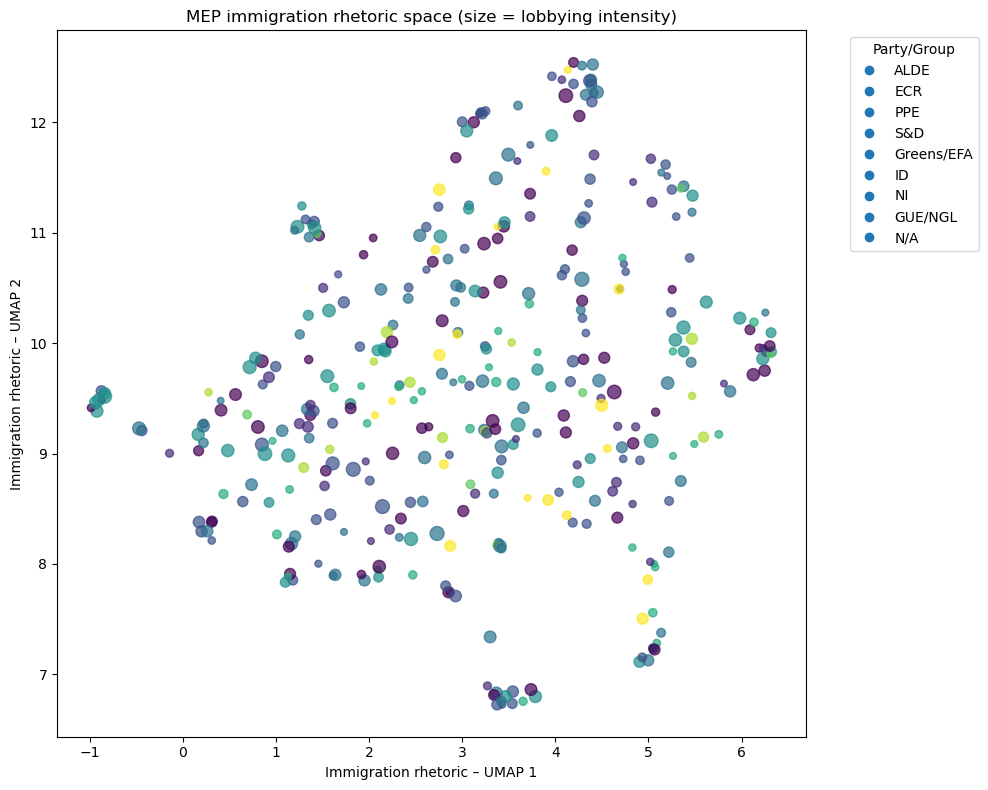

In [28]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# choose party column if available
party_col = None
for c in ["speaker_party_x", "speaker_party_y", "name"]:  # 'name' is your EP group column sometimes
    if c in docs_immigration.columns:
        party_col = c
        break

# UMAP to 2D
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

X_2d = reducer.fit_transform(X_embeddings)  # shape (n_docs, 2)

docs_immigration["umap_x"] = X_2d[:, 0]
docs_immigration["umap_y"] = X_2d[:, 1]

# lobbying intensity as a simple scalar for marker size
lobby_cols = [c for c in ["n_mep_meetings_9th", "n_mep_meetings_latest", "n_lobby_register_entries"]
              if c in docs_immigration.columns]

if lobby_cols:
    lobby_intensity = docs_immigration[lobby_cols].fillna(0).sum(axis=1)
else:
    lobby_intensity = np.ones(len(docs_immigration))

# simple scaling for marker size
sizes = 20 + 3 * np.sqrt(lobby_intensity.values)

# Plot: colour by party (if available), otherwise just one colour
plt.figure(figsize=(10, 8))

if party_col is not None:
    parties = docs_immigration[party_col].fillna("Unknown").astype(str)
    unique_parties = parties.unique()
    # map each party to an integer for colours
    party_to_int = {p: i for i, p in enumerate(unique_parties)}
    colours = [party_to_int[p] for p in parties]
    scatter = plt.scatter(
        docs_immigration["umap_x"],
        docs_immigration["umap_y"],
        c=colours,
        s=sizes,
        alpha=0.7
    )
    # build legend
    handles = []
    for p, idx in party_to_int.items():
        handles.append(
            plt.Line2D([], [], marker="o", linestyle="", label=p)
        )
    plt.legend(handles=handles, title="Party/Group", bbox_to_anchor=(1.05, 1), loc="upper left")
else:
    plt.scatter(
        docs_immigration["umap_x"],
        docs_immigration["umap_y"],
        s=sizes,
        alpha=0.7
    )

plt.xlabel("Immigration rhetoric – UMAP 1")
plt.ylabel("Immigration rhetoric – UMAP 2")
plt.title("MEP immigration rhetoric space (size = lobbying intensity)")
plt.tight_layout()
plt.show()


# Interpretation of the UMAP Immigration Rhetoric Map (coloured by party)

This plot shows a UMAP projection of MEP–year speech embeddings related to immigration.
Each point is one MEP in one year, positioned according to the semantic similarity of their speech content.

Position on the map reflects how similarly MEPs talk about immigration.

Colours represent EP political groups, highlighting partisan rhetorical patterns.

Point size corresponds to lobbying intensity, allowing comparison of lobbying exposure and rhetoric.

# What the visual reveals

Clear partisan structure:
Some political groups cluster together, indicating shared rhetorical style or framing on immigration.

Within-party variation:
Many parties are dispersed across the space, showing internal diversity in how members discuss immigration.

Lobbying intensity is not strongly tied to a single rhetorical region:
Large points appear in multiple clusters, suggesting lobbying exposure does not map to a single rhetorical style.

# Summary

The plot visualises the rhetorical landscape of immigration debates in the EP.
It shows both partisan alignment and meaningful cross-party overlap, while also allowing comparison of lobbying activity across rhetorical positions.

3. Add a simple “persona” / summary table

In [29]:
persona_cols = [
    "doc_id",
    "mep_name_clean",
    "mep_name_raw",
    "year",
    "n_immigration_votes",
]

for c in ["speaker_party_x", "speaker_party_y", "name"]:
    if c in docs_immigration.columns and c not in persona_cols:
        persona_cols.append(c)

persona_cols += lobby_cols  # from above

persona_df = docs_immigration[persona_cols].copy()
persona_df["embedding"] = docs_immigration["embedding"]

persona_df.head()


,doc_id,mep_name_clean,mep_name_raw,year,n_immigration_votes,speaker_party_x,speaker_party_y,name,n_mep_meetings_9th,n_mep_meetings_latest,n_lobby_register_entries,embedding
0,speech_abir al sahlani_y2020,abir al sahlani,Abir Al-Sahlani,2020,1.0,ALDE,N/A,Abir AL-SAHLANI,220.0,NaN,NaN,"[-0.08530665, 0.03142391, -0.013859999, -0.017..."
1,speech_abir al sahlani_y2023,abir al sahlani,Abir Al-Sahlani,2023,3.0,ALDE,N/A,Abir AL-SAHLANI,220.0,NaN,NaN,"[0.028983876, 0.04334937, -0.019151246, -0.017..."
2,speech_adam bielan_y2020,adam bielan,Adam Bielan,2020,1.0,ECR,ECR,Adam BIELAN,16.0,NaN,NaN,"[-0.00956656, -0.034002665, -0.020081775, -0.0..."
3,speech_adam bielan_y2023,adam bielan,Adam Bielan,2023,3.0,ECR,ECR,Adam BIELAN,16.0,NaN,NaN,"[-0.049928278, 0.0251647, -0.07635311, 0.01401..."
4,speech_adam jarubas_y2020,adam jarubas,Adam Jarubas,2020,1.0,PPE,PPE,Adam JARUBAS,33.0,15.0,NaN,"[-0.031256415, 0.07236513, -0.02166676, 0.0245..."


quick clustering in immigration space

c:\Users\Gebruiker\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


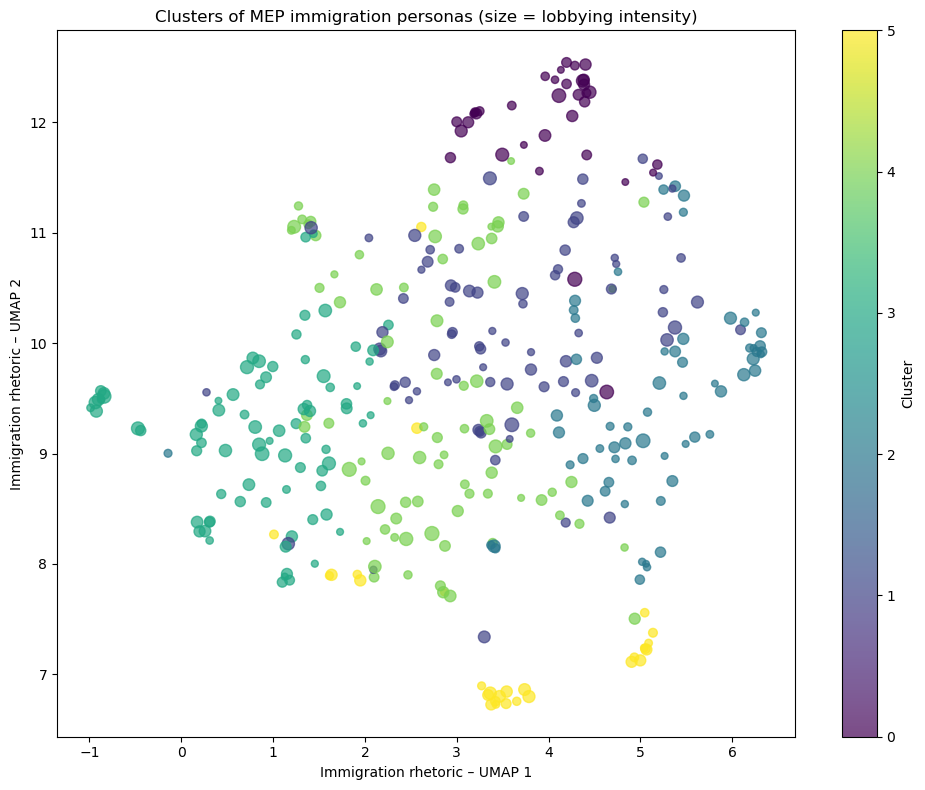

In [30]:
from sklearn.cluster import KMeans

k = 6  # choose number of clusters; tweak
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(X_embeddings)

docs_immigration["cluster"] = cluster_labels

# Plot again, coloured by cluster instead of party
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    docs_immigration["umap_x"],
    docs_immigration["umap_y"],
    c=cluster_labels,
    s=sizes,
    alpha=0.7
)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("Immigration rhetoric – UMAP 1")
plt.ylabel("Immigration rhetoric – UMAP 2")
plt.title("Clusters of MEP immigration personas (size = lobbying intensity)")
plt.tight_layout()
plt.show()


The plot shows a UMAP projection of MEP–year speech embeddings on immigration.
Each point represents one MEP in one year.

Position on the map reflects similarity in immigration rhetoric — points close together use similar language.

Colours indicate unsupervised clusters, i.e., distinct rhetorical styles on immigration.

Point size reflects lobbying intensity for that MEP-year.

Overall, the figure reveals clear groupings of rhetorical personas, suggesting that MEPs differ systematically in how they talk about immigration.
Variations in point size show how lobbying activity relates to these rhetorical patterns.

to understand clusters:

In [31]:
(
    docs_immigration
    .groupby("cluster")
    .agg(
        n_docs=("doc_id", "size"),
        avg_immig_votes=("n_immigration_votes", "mean"),
        avg_lobby_meetings=("n_mep_meetings_9th", "mean") if "n_mep_meetings_9th" in docs_immigration.columns else ("n_immigration_votes", "mean"),
    )
)


,n_docs,avg_immig_votes,avg_lobby_meetings
cluster,,,
0,36,2.277778,154.583333
1,79,2.037975,119.947368
2,64,2.125000,100.606557
3,80,1.937500,168.564103
4,84,1.904762,142.738095
5,29,2.137931,117.703704


inspect top MEPs per cluster:

In [32]:
for c_id in sorted(docs_immigration["cluster"].unique()):
    print(f"\nCluster {c_id}")
    display(
        docs_immigration[docs_immigration["cluster"] == c_id][
            ["mep_name_raw", "year", party_col, "n_immigration_votes"] + lobby_cols
        ].head(10)
    )



Cluster 0


,mep_name_raw,year,speaker_party_x,n_immigration_votes,n_mep_meetings_9th,n_mep_meetings_latest,n_lobby_register_entries
1,Abir Al-Sahlani,2023,ALDE,3.0,220.0,NaN,NaN
19,Alice Kuhnke,2023,Greens/EFA,3.0,186.0,26.0,NaN
27,Andrius Kubilius,2020,PPE,1.0,37.0,7.0,NaN
28,Andrius Kubilius,2023,PPE,3.0,37.0,7.0,NaN
29,Andrzej Halicki,2020,PPE,1.0,1.0,NaN,NaN
31,Angelika Niebler,2020,PPE,1.0,79.0,21.0,NaN
34,Angelika Winzig,2023,PPE,3.0,63.0,12.0,NaN
50,Beata Szydło,2023,ECR,3.0,1.0,NaN,NaN
57,Birgit Sippel,2020,S&D,1.0,636.0,91.0,NaN
60,Bogdan Rzońca,2023,ECR,3.0,6.0,2.0,NaN



Cluster 1


,mep_name_raw,year,speaker_party_x,n_immigration_votes,n_mep_meetings_9th,n_mep_meetings_latest,n_lobby_register_entries
17,Alexandra Geese,2023,Greens/EFA,3.0,420.0,108.0,NaN
18,Alice Kuhnke,2020,Greens/EFA,1.0,186.0,26.0,NaN
22,Anders Vistisen,2023,ID,3.0,25.0,2.0,NaN
24,Andreas Glück,2023,ALDE,3.0,151.0,18.0,NaN
25,Andreas Schieder,2020,S&D,1.0,396.0,75.0,NaN
30,Andrzej Halicki,2023,PPE,3.0,1.0,NaN,NaN
33,Angelika Winzig,2020,PPE,1.0,63.0,12.0,NaN
39,Arba Kokalari,2020,PPE,1.0,180.0,52.0,NaN
67,Charlie Weimers,2023,ECR,3.0,88.0,NaN,NaN
78,Christophe Hansen,2020,PPE,1.0,NaN,8.0,NaN



Cluster 2


...

,mep_name_raw,year,speaker_party_x,n_immigration_votes,n_mep_meetings_9th,n_mep_meetings_latest,n_lobby_register_entries
4,Adam Jarubas,2020,PPE,1.0,33.0,15.0,NaN
5,Adam Jarubas,2023,PPE,3.0,33.0,15.0,NaN
12,Alexander Bernhuber,2020,PPE,1.0,115.0,13.0,NaN
13,Alexander Bernhuber,2023,PPE,3.0,115.0,13.0,NaN
14,Alexandr Vondra,2020,ECR,1.0,94.0,13.0,NaN
20,Alicia Homs Ginel,2020,S&D,1.0,54.0,6.0,NaN
35,Anna Cavazzini,2020,Greens/EFA,1.0,333.0,NaN,NaN
41,Asger Christensen,2020,ALDE,1.0,108.0,NaN,NaN
42,Asger Christensen,2023,ALDE,3.0,108.0,NaN,NaN
43,Aurore Lalucq,2020,S&D,1.0,202.0,20.0,NaN



Cluster 4


,mep_name_raw,year,speaker_party_x,n_immigration_votes,n_mep_meetings_9th,n_mep_meetings_latest,n_lobby_register_entries
6,Adrián Vázquez Lázara,2020,ALDE,1.0,101.0,39.0,NaN
8,Alessandra Moretti,2020,S&D,1.0,32.0,10.0,NaN
9,Alessandra Moretti,2023,S&D,3.0,32.0,10.0,NaN
15,Alexandr Vondra,2023,ECR,3.0,94.0,13.0,NaN
16,Alexandra Geese,2020,Greens/EFA,1.0,420.0,108.0,NaN
21,Alicia Homs Ginel,2023,S&D,3.0,54.0,6.0,NaN
23,Andreas Glück,2020,ALDE,1.0,151.0,18.0,NaN
26,Andreas Schieder,2023,S&D,3.0,396.0,75.0,NaN
37,Anna Zalewska,2020,ECR,1.0,2.0,NaN,NaN
38,Anna Zalewska,2023,ECR,3.0,2.0,NaN,NaN



Cluster 5


,mep_name_raw,year,speaker_party_x,n_immigration_votes,n_mep_meetings_9th,n_mep_meetings_latest,n_lobby_register_entries
3,Adam Bielan,2023,ECR,3.0,16.0,NaN,NaN
7,Adrián Vázquez Lázara,2023,ALDE,3.0,101.0,39.0,NaN
10,Alex Agius Saliba,2020,S&D,1.0,223.0,NaN,NaN
32,Angelika Niebler,2023,PPE,3.0,79.0,21.0,NaN
36,Anna Cavazzini,2023,Greens/EFA,3.0,333.0,NaN,NaN
40,Arba Kokalari,2023,PPE,3.0,180.0,52.0,NaN
44,Aurore Lalucq,2023,S&D,3.0,202.0,20.0,NaN
69,Chiara Gemma,2023,ECR,3.0,6.0,3.0,NaN
79,Christophe Hansen,2023,PPE,2.0,NaN,8.0,NaN
94,Denis Nesci,2023,ECR,3.0,NaN,3.0,NaN
